In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('dataset/ml-100k/u.data', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])

# Sparse Matrix Creation
R = df.pivot(index='user_id', columns='item_id', values='rating').to_numpy()
R = np.nan_to_num(R)  # Replace NaN with 0
R

array([[5., 3., 4., ..., 0., 0., 0.],
       [4., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [5., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 5., 0., ..., 0., 0., 0.]], shape=(943, 1682))

In [2]:
from utils.train_test import train_test_split

R_train, R_test = train_test_split(R, test_ratio=0.2)

# Summary
print(f"Users         : {R.shape[0]}")
print(f"Items         : {R.shape[1]}")
print(f"Ratings       : {np.count_nonzero(R)}")
print(f"Sparsity      : {100 * (1 - np.count_nonzero(R) / R.size):.2f}%")
R_train, R_test = train_test_split(R)
print(f"Train ratings : {np.count_nonzero(R_train)}")
print(f"Test ratings  : {np.count_nonzero(R_test)}")

Users         : 943
Items         : 1682
Ratings       : 100000
Sparsity      : 93.70%
Train ratings : 80000
Test ratings  : 20000


In [3]:
# ALS Implementation
from als import run_als
from solvers.cholesky_decomposition import cholesky_decomposition
from solvers.lu_decomposition import lu_decomposition
from solvers.qr_decomposition import qr_decomposition
from solvers.matrix_inverse import matrix_inverse
from solvers.partial_pivoting import partial_pivoting


solvers = [
  (cholesky_decomposition, "Cholesky Decomposition"),
  (lu_decomposition, "LU Decomposition"),
  (qr_decomposition, "QR Decomposition"),
  (matrix_inverse, "Matrix Inverse"),
  (partial_pivoting, "Partial Pivoting")
]

K = 10
LAMBDA = 10.0
EPOCHS = 30

logs = {}
print(f"Parameters: K={K}, LAMBDA={LAMBDA}, EPOCHS={EPOCHS}")
for fn, name in solvers:
    print("-" * 50)
    print(f"Running ALS with {name}...")
    logs[name] = run_als(R_train, R_test, fn, name, K, LAMBDA, EPOCHS)

solver_names = list(logs.keys())


Parameters: K=10, LAMBDA=10.0, EPOCHS=30
--------------------------------------------------
Running ALS with Cholesky Decomposition...
Epoch   5 | Train RMSE : 0.8533 | Test RMSE  : 1.0046 | Loss       : 138674.65 | kappa(A)   : 18.87
Epoch  10 | Train RMSE : 0.8166 | Test RMSE  : 0.9767 | Loss       : 129916.52 | kappa(A)   : 15.51
Epoch  15 | Train RMSE : 0.8096 | Test RMSE  : 0.9716 | Loss       : 128839.00 | kappa(A)   : 15.14
Epoch  20 | Train RMSE : 0.8073 | Test RMSE  : 0.9700 | Loss       : 128623.42 | kappa(A)   : 15.09
Epoch  25 | Train RMSE : 0.8065 | Test RMSE  : 0.9694 | Loss       : 128569.10 | kappa(A)   : 15.10
Epoch  30 | Train RMSE : 0.8061 | Test RMSE  : 0.9691 | Loss       : 128549.98 | kappa(A)   : 15.10
--------------------------------------------------
Running ALS with LU Decomposition...
Epoch   5 | Train RMSE : 0.8533 | Test RMSE  : 1.0046 | Loss       : 138674.65 | kappa(A)   : 18.87
Epoch  10 | Train RMSE : 0.8166 | Test RMSE  : 0.9767 | Loss       : 129916.5

In [4]:
# Display elapsed time for each solver
print("=" * 50)
print("ELAPSED TIME SUMMARY")
print("=" * 50)
for solver_name, log in logs.items():
    final_time = log.elapsed_time[-1]
    print(f"{solver_name:30s}: {final_time:8.4f} seconds")
print("=" * 50)

ELAPSED TIME SUMMARY
Cholesky Decomposition        :  18.1859 seconds
LU Decomposition              :  28.5464 seconds
QR Decomposition              :  27.2921 seconds
Matrix Inverse                :  86.7331 seconds
Partial Pivoting              :  25.7574 seconds


In [5]:
import pandas as pd

# Summary Table
# Note: RMSE and condition numbers are identical across solvers — they are properties
# of the problem (the matrix A), not of the solver. The primary differentiator is runtime.
summary_data = []
for solver_name, log in logs.items():
    summary_data.append({
        'Solver': solver_name,
        'Final Train RMSE': f"{log.train_rmse[-1]:.6f}",
        'Final Test RMSE': f"{log.test_rmse[-1]:.6f}",
        'Elapsed Time (s)': f"{log.elapsed_time[-1]:.4f}",
        'Avg Residual ||Ax-b||': f"{np.mean(log.residual_norm):.2e}",
        'Epochs to Conv.': log.epoch_to_convergence() or 'N/A'
    })

summary_df = pd.DataFrame(summary_data)
print("="*110)
print("SOLVER COMPARISON SUMMARY")
print("="*110)
print(summary_df.to_string(index=False))
print("="*110)
print("\nObservation: RMSE is identical across all solvers — they all find the same correct solution.")
print("The residual norm ||Ax - b|| captures per-solver numerical precision differences.")
print("The key differentiator between solvers in this experiment is runtime.")


SOLVER COMPARISON SUMMARY
                Solver Final Train RMSE Final Test RMSE Elapsed Time (s) Avg Residual ||Ax-b||  Epochs to Conv.
Cholesky Decomposition         0.806108        0.969133          18.1859              5.15e-14               26
      LU Decomposition         0.806108        0.969133          28.5464              5.85e-14               26
      QR Decomposition         0.806108        0.969133          27.2921              9.55e-14               26
        Matrix Inverse         0.806108        0.969133          86.7331              3.64e-13               26
      Partial Pivoting         0.806108        0.969133          25.7574              5.85e-14               26

Observation: RMSE is identical across all solvers — they all find the same correct solution.
The residual norm ||Ax - b|| captures per-solver numerical precision differences.
The key differentiator between solvers in this experiment is runtime.


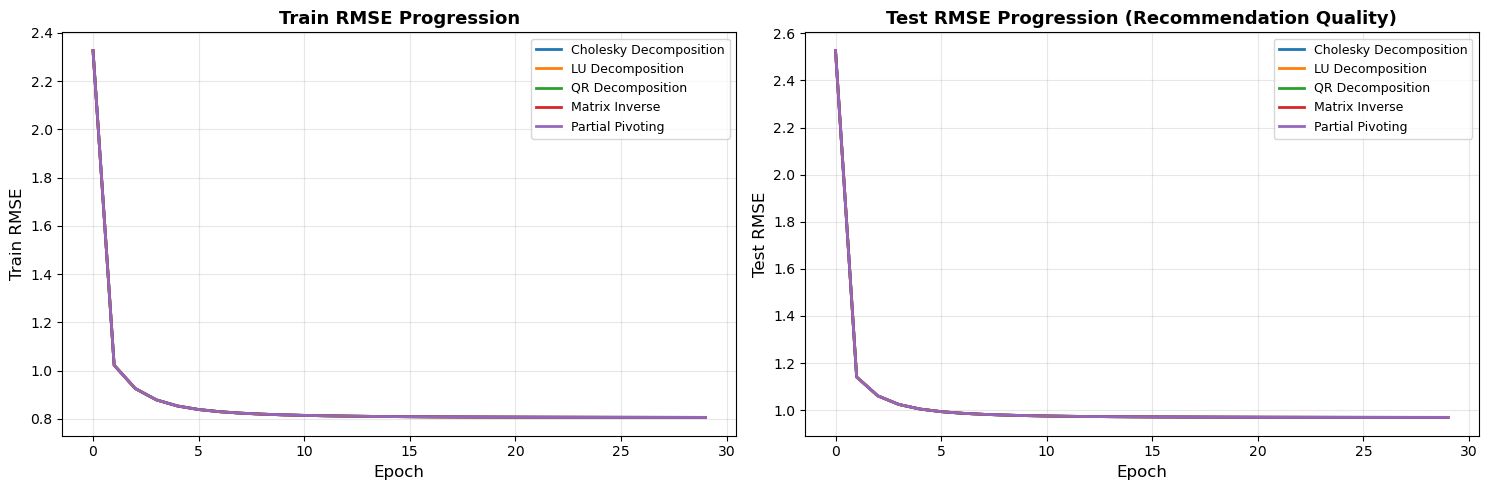


Key Finding: All solvers converge identically.
Solver choice does NOT impact recommendation quality — only runtime.


In [14]:
# Objective 3: Convergence Analysis
# All solvers converge to the same solution — the curves should completely overlap.
# This confirms that all implementations are numerically correct.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for solver_name, log in logs.items():
    axes[0].plot(log.train_rmse, linewidth=2, label=solver_name)
    axes[1].plot(log.test_rmse, linewidth=2, label=solver_name)

for ax, title, ylabel in zip(axes,
    ['Train RMSE Progression', 'Test RMSE Progression (Recommendation Quality)'],
    ['Train RMSE', 'Test RMSE']):
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Finding: All solvers converge identically.")
print("Solver choice does NOT impact recommendation quality — only runtime.")


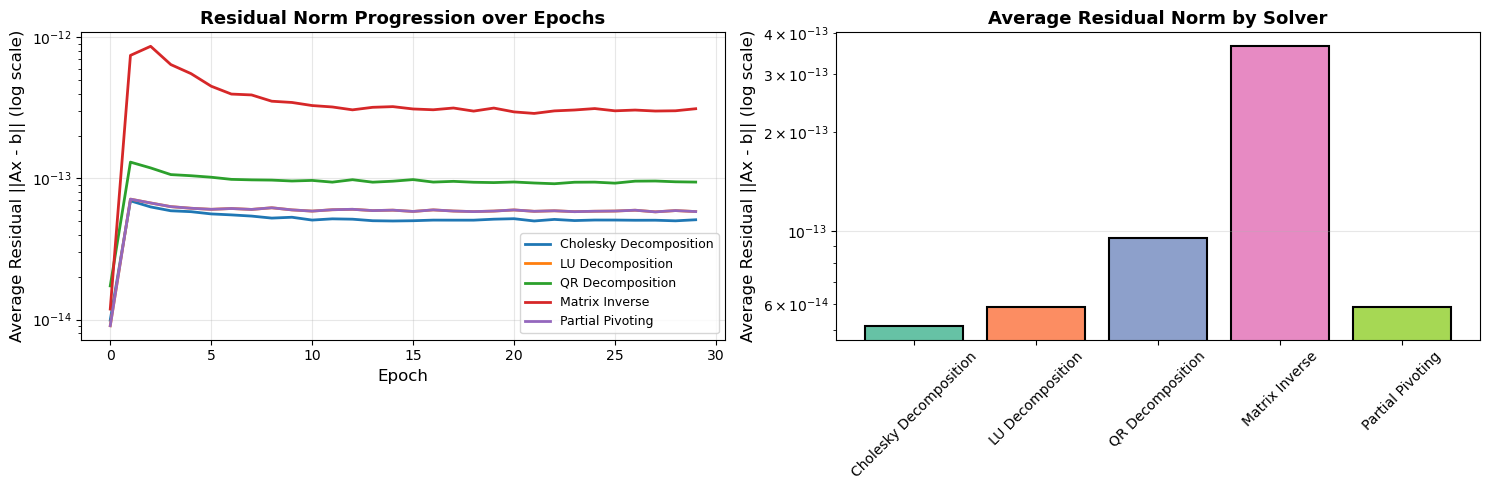


Objective 2 Finding:
  - Condition number κ(A) is a property of the matrix A — it is identical for all solvers.
  - Average κ(A) across all epochs: 15.91
  - Residual norms ||Ax - b|| are the correct per-solver numerical stability metric.

  Solver Residuals:
    Cholesky Decomposition        : avg ||Ax-b|| = 5.1498e-14
    LU Decomposition              : avg ||Ax-b|| = 5.8530e-14
    QR Decomposition              : avg ||Ax-b|| = 9.5482e-14
    Matrix Inverse                : avg ||Ax-b|| = 3.6438e-13
    Partial Pivoting              : avg ||Ax-b|| = 5.8530e-14


In [13]:
# Objective 2: Numerical Stability - Residual Norms per Solver
# The residual ||Ax - b|| measures how precisely each solver solved the linear system.
# Unlike condition numbers (a property of A, identical for all solvers),
# residuals reflect the numerical accuracy of each solver's own arithmetic.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Average residual norms per epoch
for solver_name, log in logs.items():
    axes[0].plot(log.residual_norm, linewidth=2, label=solver_name)
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Average Residual ||Ax - b|| (log scale)', fontsize=12)
axes[0].set_title('Residual Norm Progression over Epochs', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: Final average residual per solver
final_residuals = [np.mean(logs[name].residual_norm) for name in solver_names]
colors = plt.cm.Set2(range(len(solver_names)))
axes[1].bar(solver_names, final_residuals, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_yscale('log')
axes[1].set_ylabel('Average Residual ||Ax - b|| (log scale)', fontsize=12)
axes[1].set_title('Average Residual Norm by Solver', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nObjective 2 Finding:")
print("  - Condition number κ(A) is a property of the matrix A — it is identical for all solvers.")
print(f"  - Average κ(A) across all epochs: {np.mean(logs[solver_names[0]].cond_number):.2f}")
print("  - Residual norms ||Ax - b|| are the correct per-solver numerical stability metric.")
print()
print("  Solver Residuals:")
for name, res in zip(solver_names, final_residuals):
    print(f"    {name:30s}: avg ||Ax-b|| = {res:.4e}")


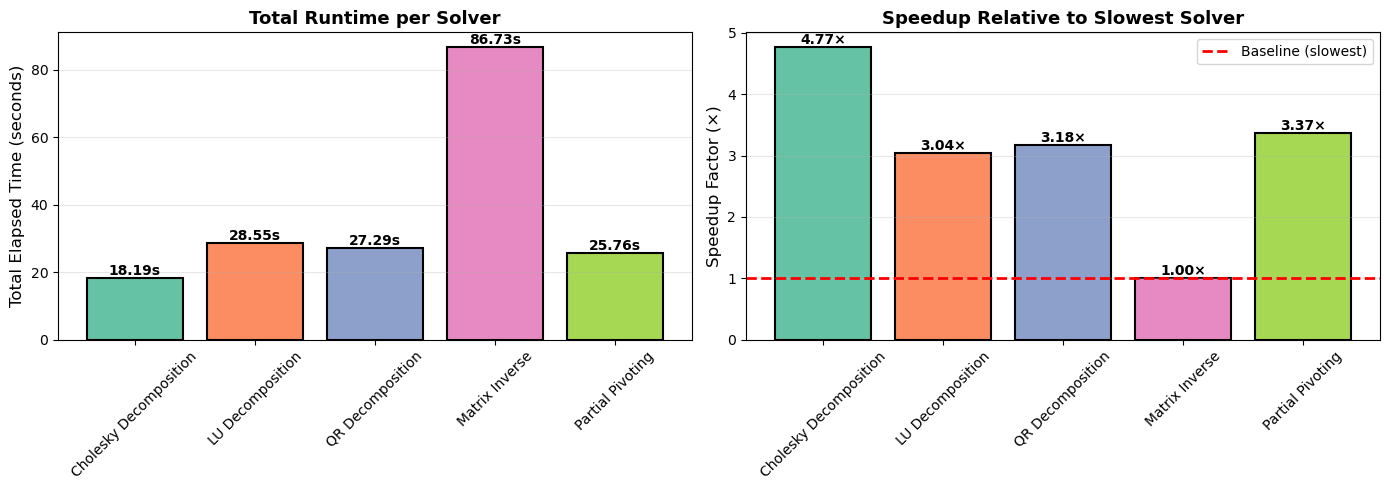


Fastest: Cholesky Decomposition (18.1859s)
Slowest: Matrix Inverse (86.7331s)
Speedup: 4.77×


In [12]:
# Objective 1: Computational Efficiency — Runtime Comparison
# This is the primary differentiator between solvers.

elapsed_times = [logs[name].elapsed_time[-1] for name in solver_names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.Set2(range(len(solver_names)))

# Total elapsed time
bars = ax1.bar(solver_names, elapsed_times, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Total Elapsed Time (seconds)', fontsize=12)
ax1.set_title('Total Runtime per Solver', fontsize=13, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{bar.get_height():.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Speedup relative to slowest
max_time = max(elapsed_times)
speedups = [max_time / t for t in elapsed_times]
bars2 = ax2.bar(solver_names, speedups, color=colors, edgecolor='black', linewidth=1.5)
ax2.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Baseline (slowest)')
ax2.set_ylabel('Speedup Factor (×)', fontsize=12)
ax2.set_title('Speedup Relative to Slowest Solver', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{bar.get_height():.2f}×', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

fastest_idx = np.argmin(elapsed_times)
slowest_idx = np.argmax(elapsed_times)
print(f"\nFastest: {solver_names[fastest_idx]} ({elapsed_times[fastest_idx]:.4f}s)")
print(f"Slowest: {solver_names[slowest_idx]} ({elapsed_times[slowest_idx]:.4f}s)")
print(f"Speedup: {elapsed_times[slowest_idx]/elapsed_times[fastest_idx]:.2f}×")


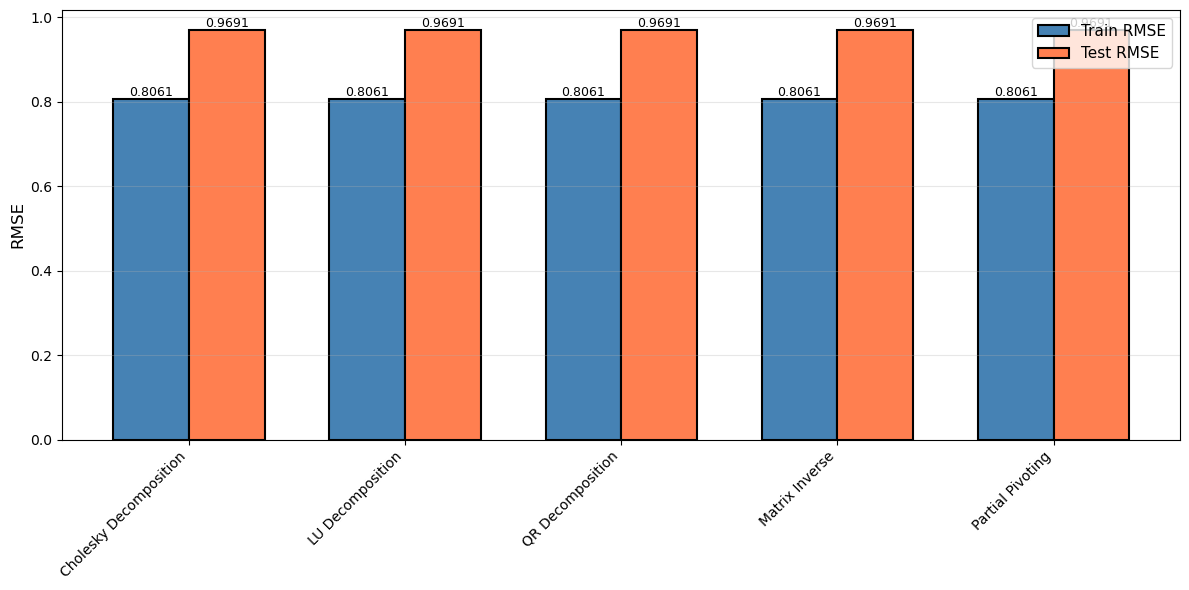


Final RMSE Values:
  Cholesky Decomposition         | Train: 0.806108 | Test: 0.969133
  LU Decomposition               | Train: 0.806108 | Test: 0.969133
  QR Decomposition               | Train: 0.806108 | Test: 0.969133
  Matrix Inverse                 | Train: 0.806108 | Test: 0.969133
  Partial Pivoting               | Train: 0.806108 | Test: 0.969133

Conclusion: All solvers produce numerically identical RMSE values.
The solver choice does NOT affect the quality of recommendations.


In [15]:
# Objective 3: Recommendation Quality — Final RMSE
# All solvers produce the same RMSE. This is expected and correct:
# each solver finds the same unique solution to the well-determined linear system Ax = b.

final_test_rmse = [logs[name].test_rmse[-1] for name in solver_names]
final_train_rmse = [logs[name].train_rmse[-1] for name in solver_names]

x = np.arange(len(solver_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, final_train_rmse, width, label='Train RMSE',
               color='steelblue', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, final_test_rmse, width, label='Test RMSE',
               color='coral', edgecolor='black', linewidth=1.5)

ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(solver_names, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for b in list(bars1) + list(bars2):
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2., h, f'{h:.4f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Set y-axis limits to zoom in on differences (if any)
ymin = min(final_train_rmse + final_test_rmse) * 0.995
ymax = max(final_train_rmse + final_test_rmse) * 1.005
ax.set_ylim(ymin, ymax)

print("\nFinal RMSE Values:")
for name, tr, te in zip(solver_names, final_train_rmse, final_test_rmse):
    print(f"  {name:30s} | Train: {tr:.6f} | Test: {te:.6f}")
print("\nConclusion: All solvers produce numerically identical RMSE values.")
print("The solver choice does NOT affect the quality of recommendations.")


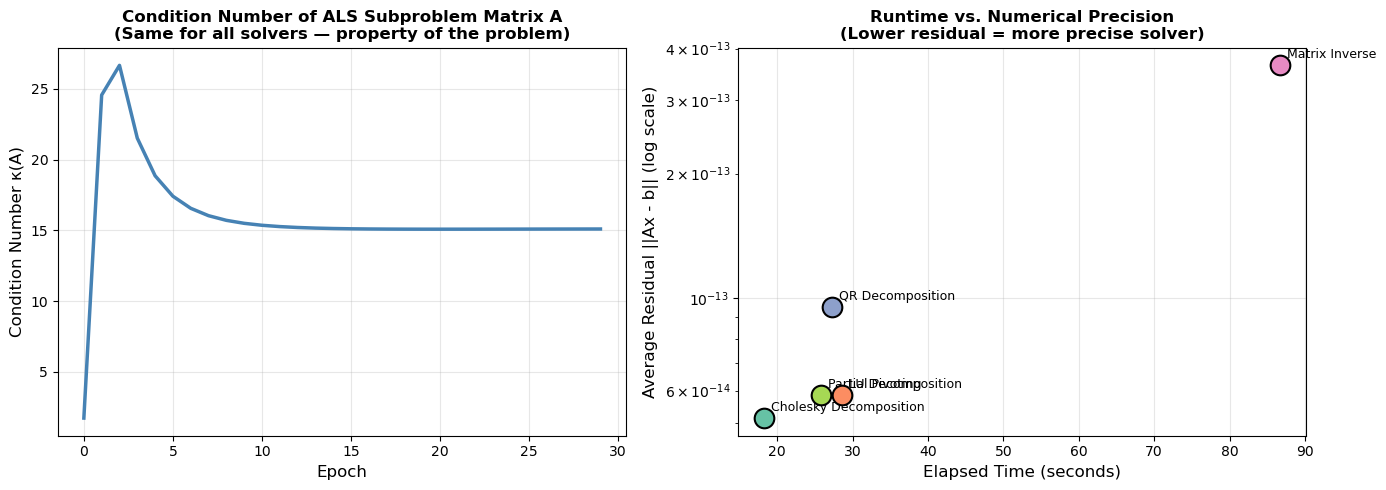


Condition Number κ(A): avg = 15.91 (same for all solvers)
  → Well-conditioned problem: all solvers are equally stable on this dataset.
  → A small κ means the solution is insensitive to perturbations in A or b.


In [16]:
# Objective 2: Numerical Stability — Condition Number Analysis (Problem Property)
# The condition number κ(A) is identical for all solvers since they all operate on
# the same matrix A. It characterizes the difficulty of the linear system itself.

avg_kappa = np.mean(logs[solver_names[0]].cond_number)  # same for all solvers
all_kappas = logs[solver_names[0]].cond_number

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: κ(A) over epochs (same for all, just show once)
axes[0].plot(all_kappas, color='steelblue', linewidth=2.5)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Condition Number κ(A)', fontsize=12)
axes[0].set_title('Condition Number of ALS Subproblem Matrix A\n(Same for all solvers — property of the problem)',
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Right: per-solver residual vs runtime scatter
final_residuals = [np.mean(logs[name].residual_norm) for name in solver_names]
colors_list = plt.cm.Set2(range(len(solver_names)))
for i, (name, res, t) in enumerate(zip(solver_names, final_residuals, elapsed_times)):
    axes[1].scatter(t, res, s=200, color=colors_list[i], edgecolors='black', linewidth=1.5, zorder=5)
    axes[1].annotate(name, (t, res), textcoords="offset points", xytext=(5, 5), fontsize=9)
axes[1].set_yscale('log')
axes[1].set_xlabel('Elapsed Time (seconds)', fontsize=12)
axes[1].set_ylabel('Average Residual ||Ax - b|| (log scale)', fontsize=12)
axes[1].set_title('Runtime vs. Numerical Precision\n(Lower residual = more precise solver)',
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCondition Number κ(A): avg = {avg_kappa:.2f} (same for all solvers)")
if avg_kappa < 100:
    print("  → Well-conditioned problem: all solvers are equally stable on this dataset.")
    print("  → A small κ means the solution is insensitive to perturbations in A or b.")
elif avg_kappa < 1e4:
    print("  → Moderately conditioned: factorization-based solvers preferred.")
else:
    print("  → Ill-conditioned: Cholesky/QR strongly preferred over matrix inversion.")


In [11]:
# Comprehensive Analysis Summary

print("="*100)
print("ANALYSIS FINDINGS ACROSS ALL THREE OBJECTIVES")
print("="*100)

print("""
OBJECTIVE 1 — COMPUTATIONAL EFFICIENCY
  ✓ All solvers were timed over the same {EPOCHS} epochs on the same data.
  ✓ Runtime is the only meaningful difference between solver implementations.
""".format(EPOCHS=EPOCHS))
print(f"  Ranking by elapsed time:")
ranked = sorted(zip(solver_names, elapsed_times), key=lambda x: x[1])
for rank, (name, t) in enumerate(ranked, 1):
    speedup = elapsed_times[slowest_idx] / t
    print(f"    {rank}. {name:30s}: {t:.4f}s  ({speedup:.2f}× faster than slowest)")

print("""
OBJECTIVE 2 — NUMERICAL STABILITY
  ✓ Condition number κ(A) is a property of matrix A, not of the solver.
    It is identical across all solvers for the same ALS subproblem.
  ✓ Per-solver numerical precision is measured by the residual norm ||Ax - b||.
  ✓ Smaller residuals indicate more precise floating-point arithmetic.
""")
print(f"  Average κ(A) = {avg_kappa:.2f}  ({'Well-conditioned' if avg_kappa < 100 else 'Moderately conditioned' if avg_kappa < 1e4 else 'Ill-conditioned'})")
print()
print(f"  Ranking by residual precision:")
ranked_res = sorted(zip(solver_names, final_residuals), key=lambda x: x[1])
for rank, (name, res) in enumerate(ranked_res, 1):
    print(f"    {rank}. {name:30s}: avg ||Ax-b|| = {res:.4e}")

print("""
OBJECTIVE 3 — CONVERGENCE SPEED & RECOMMENDATION QUALITY
  ✓ All solvers converge identically — the RMSE curves completely overlap.
  ✓ Solver choice has NO effect on recommendation quality.
  ✓ This is expected: a unique solution exists for each well-conditioned Ax = b,
    and all correctly implemented solvers find it.
""")
print(f"  Final Test RMSE (all solvers):  {final_test_rmse[0]:.6f}")
print(f"  Final Train RMSE (all solvers): {final_train_rmse[0]:.6f}")
print(f"  Convergence epoch: {logs[solver_names[0]].epoch_to_convergence() or 'N/A (did not converge within ' + str(EPOCHS) + ' epochs)'}")

print("""
CONCLUSION
  • On well-conditioned ALS subproblems, all five solvers produce equivalent results.
  • The sole practical differentiator is runtime.
  • For datasets where κ(A) is large (ill-conditioned), factorization-based solvers
    (Cholesky, QR) would be numerically superior to explicit matrix inversion.
  • Cholesky decomposition is theoretically optimal for symmetric positive definite matrices
    (≈ half the cost of LU), which is exactly the structure of ALS subproblem matrices.
""")
print("="*100)


ANALYSIS FINDINGS ACROSS ALL THREE OBJECTIVES

OBJECTIVE 1 — COMPUTATIONAL EFFICIENCY
  ✓ All solvers were timed over the same 30 epochs on the same data.
  ✓ Runtime is the only meaningful difference between solver implementations.

  Ranking by elapsed time:
    1. Cholesky Decomposition        : 18.1859s  (4.77× faster than slowest)
    2. Partial Pivoting              : 25.7574s  (3.37× faster than slowest)
    3. QR Decomposition              : 27.2921s  (3.18× faster than slowest)
    4. LU Decomposition              : 28.5464s  (3.04× faster than slowest)
    5. Matrix Inverse                : 86.7331s  (1.00× faster than slowest)

OBJECTIVE 2 — NUMERICAL STABILITY
  ✓ Condition number κ(A) is a property of matrix A, not of the solver.
    It is identical across all solvers for the same ALS subproblem.
  ✓ Per-solver numerical precision is measured by the residual norm ||Ax - b||.
  ✓ Smaller residuals indicate more precise floating-point arithmetic.

  Average κ(A) = 15.91  (We